# Sales Prediction Using Python

## Objective
The objective of this project is to predict product sales based on advertising expenditure on TV, Radio, and Newspaper using Linear Regression.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# Load dataset

df = pd.read_csv("../data/Advertising.csv")

In [3]:
# Display first 5 rows

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Number of rows and columns

df.shape

(200, 5)

In [5]:
# Information about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
# Statistical summary

df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
# Check missing values

df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [8]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [9]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [10]:
# Display all column names

df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [11]:
# Correlation matrix

df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


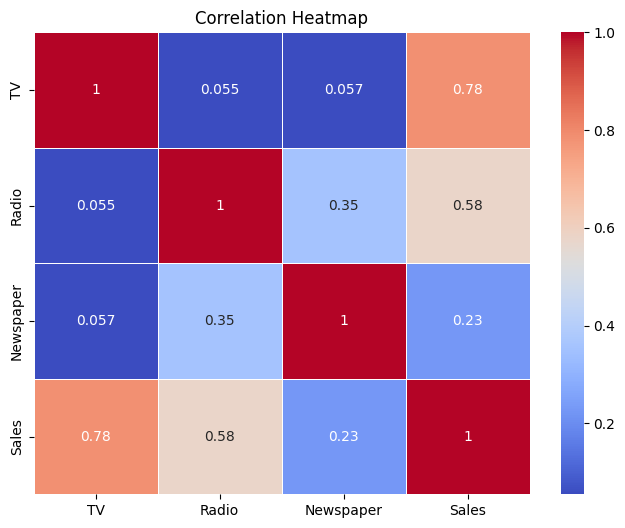

In [12]:
# Plot heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Observation

- TV has the highest positive correlation with Sales.
- Radio has a moderate positive correlation with Sales.
- Newspaper has the weakest correlation with Sales.

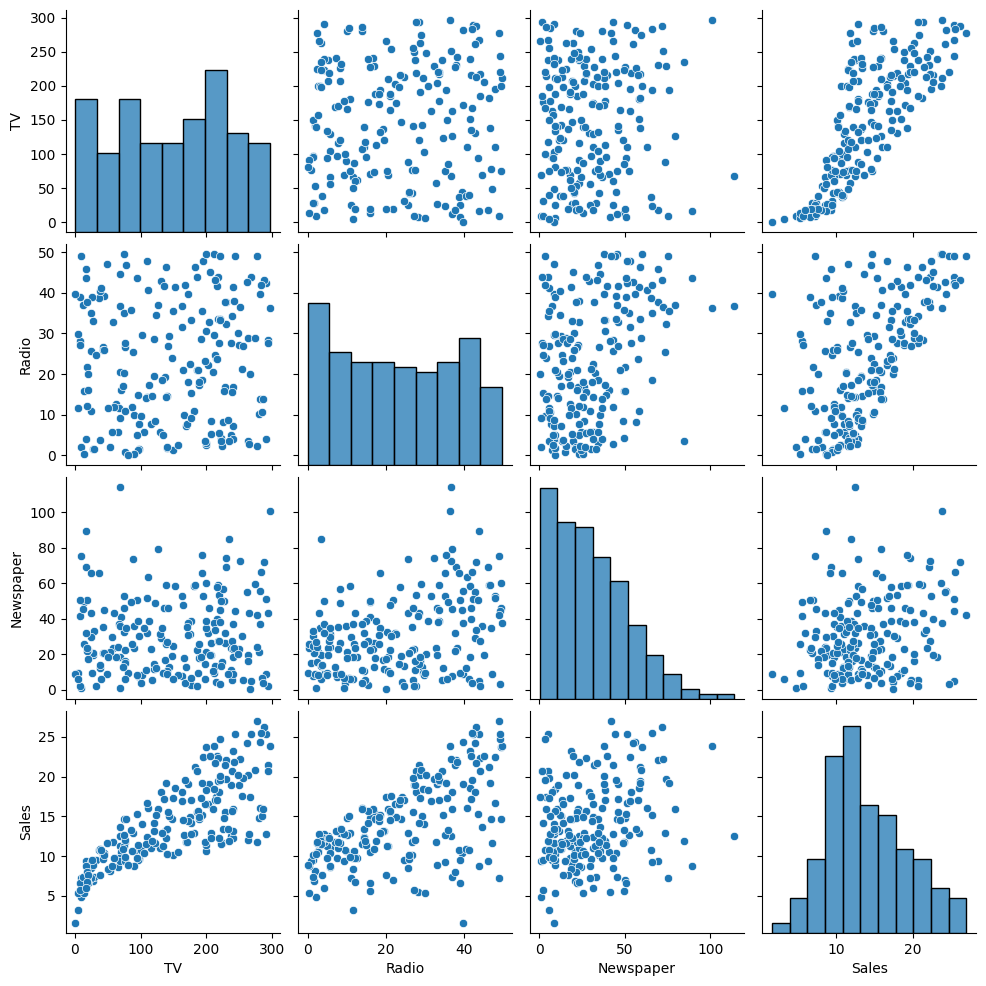

In [13]:
# Pairplot

sns.pairplot(df)

plt.show()

### Observation

- Sales increases as TV advertising increases.
- Radio also shows a positive relationship with Sales.
- Newspaper has a weaker relationship with Sales.

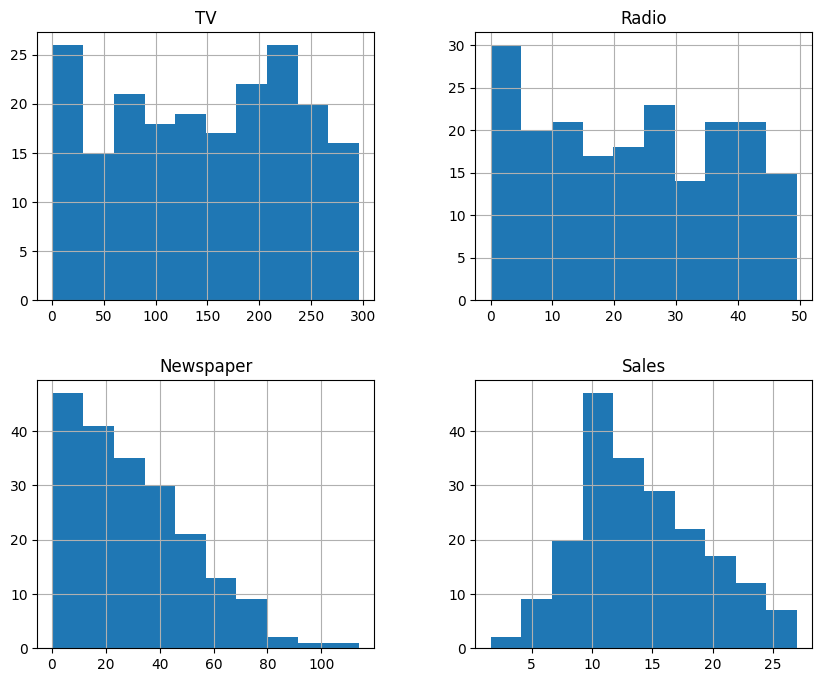

In [14]:
# Histogram of all numerical columns

df.hist(figsize=(10,8))

plt.show()

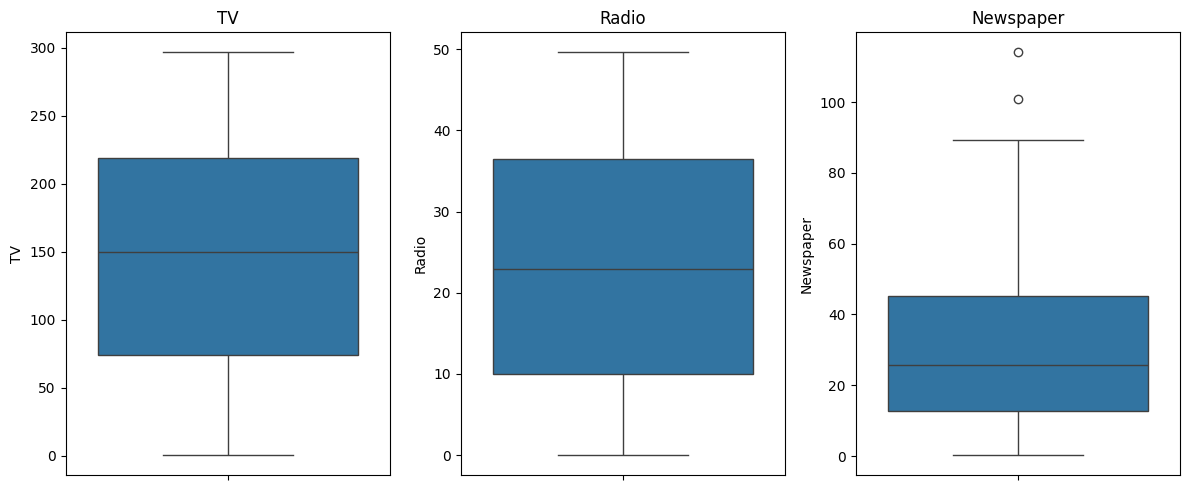

In [15]:
# Boxplots

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.boxplot(y=df["TV"])
plt.title("TV")

plt.subplot(1,3,2)
sns.boxplot(y=df["Radio"])
plt.title("Radio")

plt.subplot(1,3,3)
sns.boxplot(y=df["Newspaper"])
plt.title("Newspaper")

plt.tight_layout()

plt.show()

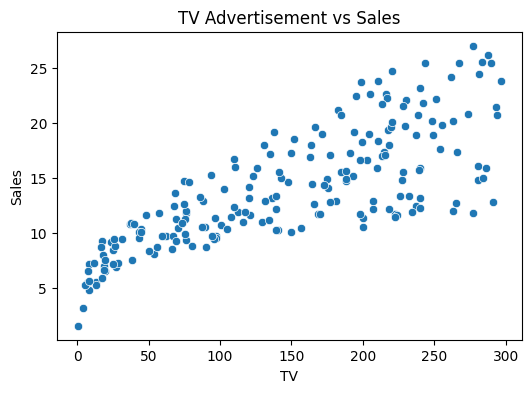

In [16]:
# TV vs Sales

plt.figure(figsize=(6,4))

sns.scatterplot(x="TV", y="Sales", data=df)

plt.title("TV Advertisement vs Sales")

plt.show()

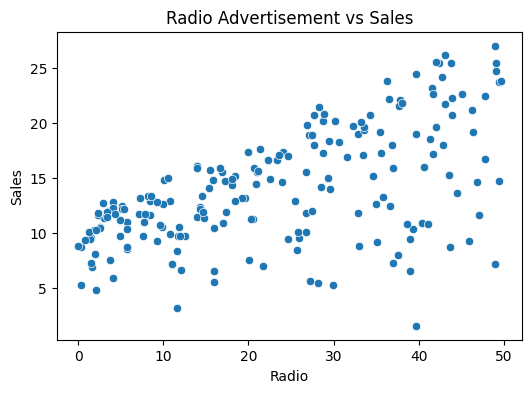

In [17]:
# Radio vs Sales

plt.figure(figsize=(6,4))

sns.scatterplot(x="Radio", y="Sales", data=df)

plt.title("Radio Advertisement vs Sales")

plt.show()

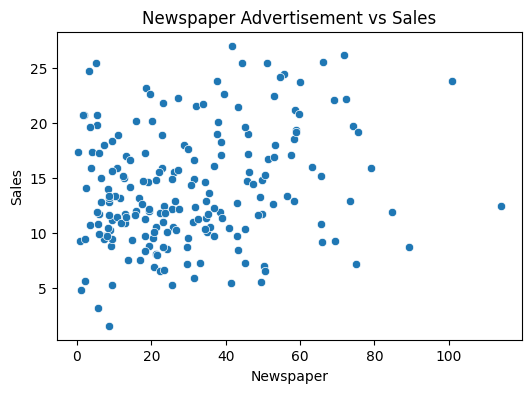

In [18]:
# Newspaper vs Sales

plt.figure(figsize=(6,4))

sns.scatterplot(x="Newspaper", y="Sales", data=df)

plt.title("Newspaper Advertisement vs Sales")

plt.show()

In [19]:
# Independent variables

X = df[['TV', 'Radio', 'Newspaper']]

# Dependent variable

y = df['Sales']

In [20]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [21]:
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [22]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (160, 3)
Testing Data: (40, 3)


In [24]:
# Create Linear Regression model

model = LinearRegression()

In [25]:
# Train the model

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# Predict sales for test data

y_pred = model.predict(X_test)

In [27]:
y_pred[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

In [28]:
# Compare actual and predicted sales

comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


In [29]:
# Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.4607567168117603


In [30]:
# Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 3.1740973539761033


In [31]:
# Root Mean Squared Error

rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1.78159966153345


In [32]:
# R² Score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.899438024100912


In [33]:
print("Model Performance")
print("-" * 30)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Performance
------------------------------
MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE: 1.78159966153345
R² Score: 0.899438024100912


In [34]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [35]:
print("Intercept:", model.intercept_)

Intercept: 2.979067338122629


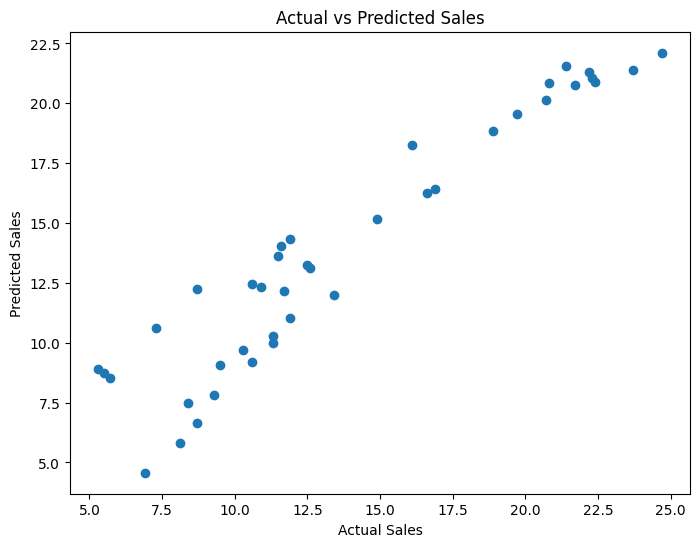

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

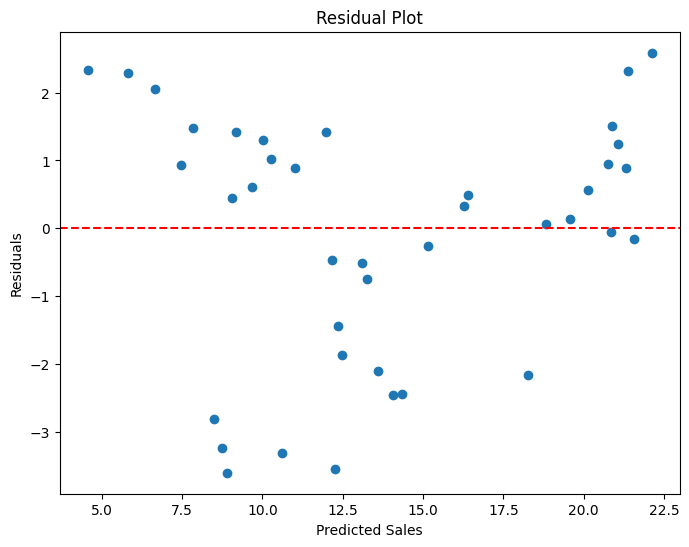

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [38]:
new_data = pd.DataFrame({
    "TV": [200],
    "Radio": [30],
    "Newspaper": [20]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 17.656044745724536


# Business Insights

- TV advertising has the strongest impact on sales.
- Radio advertising also contributes positively to sales.
- Newspaper advertising has the least impact on sales.
- Increasing investment in TV and Radio advertisements is likely to increase sales.
- Companies should optimize their advertising budget by focusing more on TV and Radio campaigns.

# Conclusion

This project successfully predicted product sales using Linear Regression.

The model achieved a high R² Score, indicating that advertising expenditure is a strong predictor of sales.

Among the advertising channels:
- TV has the highest influence.
- Radio has a moderate influence.
- Newspaper has the least influence.

The developed model can help businesses estimate future sales and make informed advertising budget decisions.